# Logistic Regression from Scratch

This notebook demonstrates binary classification using logistic regression implemented from scratch.

In [2]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

from ml_scratch.linear_model.logistic_regression import LogisticRegression
from ml_scratch.metrics import accuracy_score

## 1. Generate Classification Data

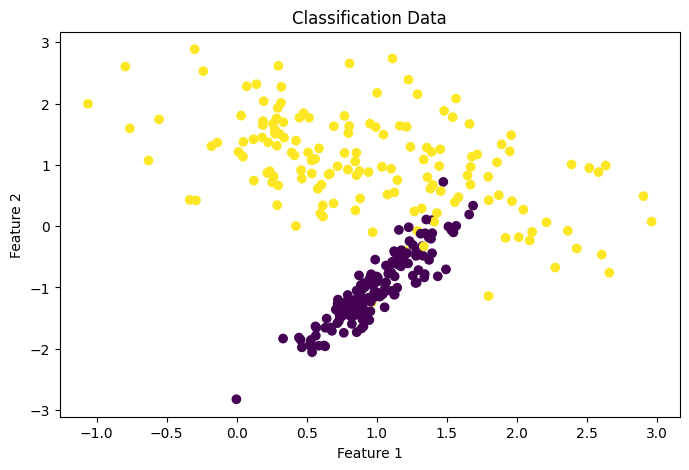

In [5]:
X, y = make_classification(
    n_samples=300,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    random_state=42
)

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Classification Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## 2. Model Overview

Logistic regression uses the sigmoid function to map linear outputs to probabilities:

σ(z) = 1 / (1 + e^-z)

The final prediction is made by thresholding the probability.

In [4]:
model = LogisticRegression(lr=0.1, n_iters=1000)
model.fit(X, y)

y_pred = model.predict(X)
acc = accuracy_score(y, y_pred)
print("Accuracy:", acc)

Accuracy: 0.9233333333333333


## 3. Decision Boundary

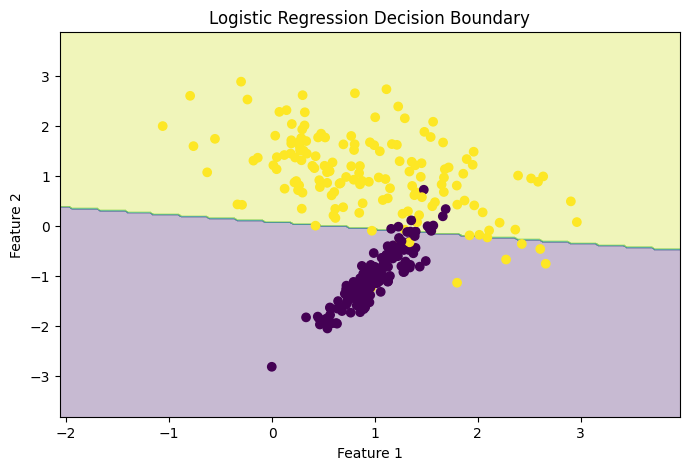

In [6]:
xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200),
    np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid).reshape(xx.shape)

plt.figure(figsize=(8, 5))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Logistic Regression Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## 4. Loss Curve

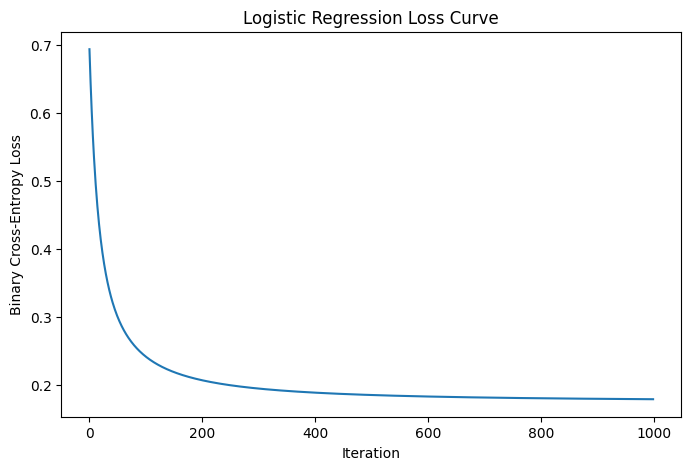

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(model.loss_history)
plt.title("Logistic Regression Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Binary Cross-Entropy Loss")
plt.show()

## 5. Conclusion

- Logistic regression is effective for binary classification with a linear decision boundary.
- The sigmoid function allows the model to output probabilities.
- The model performed well on this synthetic dataset.